In [1]:
import qiskit as qi

from spin_pulse import PulseCircuit
from spin_pulse.environment.noise import NoiseType
from spin_pulse.transpilation.hardware_specs import HardwareSpecs, Shape

In [2]:
# Define hardware
num_qubits = 3

B_field = 0.5
delta = 0.2
J_coupling = 0.01

hardware_specs = HardwareSpecs(
    num_qubits=num_qubits,
    B_field=B_field,
    delta=delta,
    J_coupling=J_coupling,
    rotation_shape=Shape.GAUSSIAN,
    ramp_duration=5,
    optim=3,
)

| Parameter        | Meaning                                  |
| ---------------- | ---------------------------------------- |
| `num_qubits`     | Number of qubits                         |
| `B_field`        | Maximum magnetic field strength          |
| `delta`          | Maximum energy difference between qubits |
| `J_coupling`     | Coupling strength between qubits         |
| `Shape.GAUSSIAN` | Gaussian pulse envelope                  |
| `Shape.SQUARE`   | Square pulse envelope                    |
| `ramp_duration`  | Ramp duration                            |
| `optim`          | Qiskit transpilation optimization level  |

In [3]:
# Define a circuit
qreg = qi.QuantumRegister(num_qubits)
circ = qi.QuantumCircuit(qreg)

circ.h(0)
circ.cx(0, 1)
circ.rz(0.5, 2)

circ.draw()

┌───┐        
q0_0: ───┤ H ├─────■──
         └───┘   ┌─┴─┐
q0_1: ───────────┤ X ├
      ┌─────────┐└───┘
q0_2: ┤ Rz(0.5) ├─────
      └─────────┘

In [4]:
# Transpile to SpinPulse native gates
isa_circ = hardware_specs.gate_transpile(circ)
isa_circ.draw()

global phase: 5π/4
          ┌─────────┐                                               »
q0_2 -> 0 ┤ Rz(0.5) ├───────────────────────────────────────────────»
          ├─────────┴┐ ┌────────────┐           ┌───────┐           »
q0_1 -> 1 ┤ Ry(-π/2) ├─┤ Rz(2.1267) ├─■─────────┤ Rx(π) ├─■─────────»
          ├─────────┬┘┌┴────────────┤ │ZZ(-π/4) ├───────┤ │ZZ(-π/4) »
q0_0 -> 2 ┤ Ry(π/2) ├─┤ Rz(-1.0176) ├─■─────────┤ Rx(π) ├─■─────────»
          └─────────┘ └─────────────┘           └───────┘           »
«                                                
«q0_2 -> 0 ──────────────────────────────────────
«           ┌────────────┐┌─────────┐┌──────────┐
«q0_1 -> 1 ─┤ Rz(2.1267) ├┤ Rx(π/2) ├┤ Rz(-π/2) ├
«          ┌┴────────────┤└─────────┘└──────────┘
«q0_0 -> 2 ┤ Rz(-2.5884) ├───────────────────────
«          └─────────────┘

In [5]:
# Convert to physical pulses
pulse_circuit = PulseCircuit.from_circuit(
    isa_circ,
    hardware_specs,
)

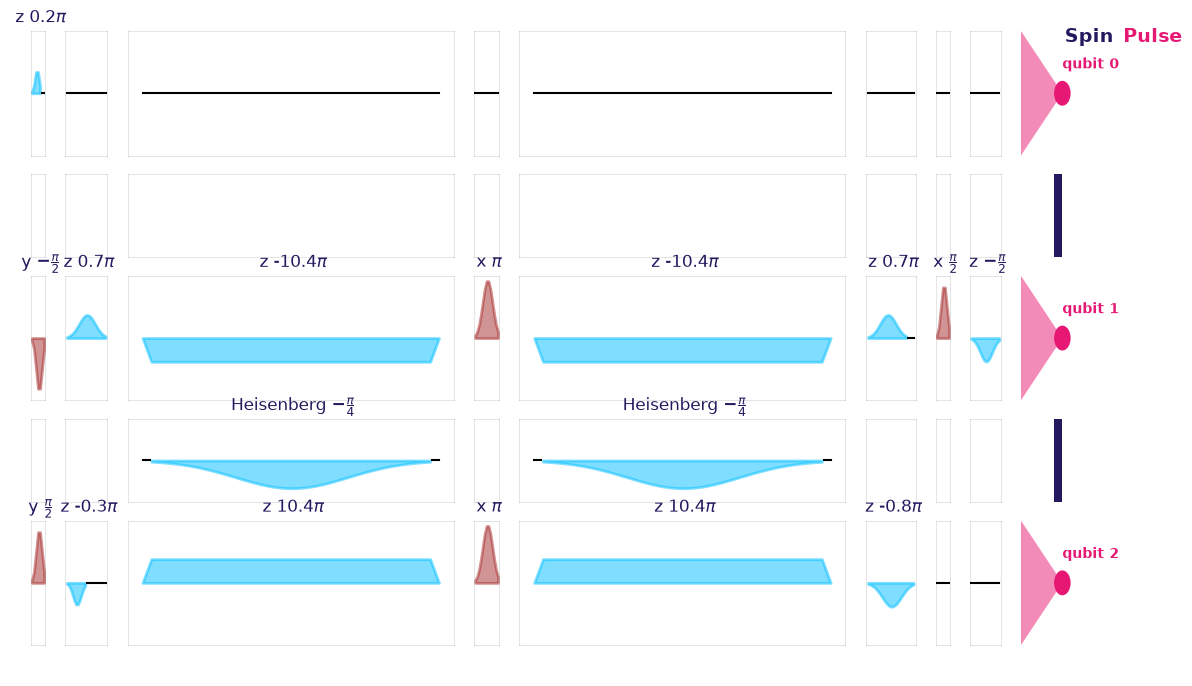

In [6]:
# Plot pulses
pulse_circuit.plot(
    hardware_specs=hardware_specs
)

In [7]:
# Numerically integrate pulses
implemented_circ = pulse_circuit.to_circuit()
implemented_circ.draw()

global phase: 5π/4
          ┌──────┐┌───────┐ ┌────────┐┌───────┐ ┌────────┐┌───────┐┌──────┐»
q0_2 -> 0 ┤ 1q_7 ├┤ 1q_22 ├─┤ 1q_169 ├┤ 1q_13 ├─┤ 1q_169 ├┤ 1q_26 ├┤ 1q_7 ├»
          ├──────┤├───────┤┌┴────────┤├───────┤┌┴────────┤├───────┤├──────┤»
q0_1 -> 1 ┤ 1q_7 ├┤ 1q_22 ├┤0        ├┤ 1q_13 ├┤0        ├┤ 1q_26 ├┤ 1q_7 ├»
          ├──────┤├───────┤│  2q_169 │├───────┤│  2q_169 │├───────┤├──────┤»
q0_0 -> 2 ┤ 1q_7 ├┤ 1q_22 ├┤1        ├┤ 1q_13 ├┤1        ├┤ 1q_26 ├┤ 1q_7 ├»
          └──────┘└───────┘└─────────┘└───────┘└─────────┘└───────┘└──────┘»
«          ┌───────┐
«q0_2 -> 0 ┤ 1q_16 ├
«          ├───────┤
«q0_1 -> 1 ┤ 1q_16 ├
«          ├───────┤
«q0_0 -> 2 ┤ 1q_16 ├
«          └───────┘

In [8]:
# Calculate fidelity
print(
    "Pulse-level fidelity:",
    pulse_circuit.fidelity(),
)

Pulse-level fidelity: 0.9999996570953991
